# **_Generalized Eigendecomposition: Two Methods_**

Analyzing eigenvalues and eigenvectors of $A v = \lambda B v$ via both direct generalized eigendecomposition `eig(A, B)` and the equivalent standard eigenproblem form $B^{-1}A v = \lambda v$.

<hr style="height: 0; box-shadow: 0 0 5px 4px crimson; width: 95%;">

## **_Goals_**

**_1._** Demonstrate that the generalized eigenproblem $A v = \lambda B v$ and the transformed form $B^{-1}A v = \lambda v$ yield identical eigenvalues up to numerical error.

**_2._** Demonstrate that the eigenvectors from both formulations correspond to the same invariant directions.

##### **_Interpretation Note:_**

Any small differences observed in eigenvectors are expected and arise from scaling ambiguity and finite-precision numerical effects, not from a difference in the underlying solution.

<hr style="height: 0; box-shadow: 0 0 5px 4px crimson; width: 95%;">

## **_Code and Analysis_**

<hr style="height: 0; box-shadow: 0 0 5px 4px dodgerblue; width: 80%;">

### **_Prepare Data_**

In [18]:
# Import libraries:
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg
from sympy import sympify

In [19]:
# Define square matrix dimensions:
N = 10

# Create matrix A and force symmetry:
X = np.random.randn(N, N)
A = X @ X.T
# Verify shape and full-rank:
print(np.shape(A))
print(np.linalg.matrix_rank(A))

Y = np.random.randn(N, N)
# Create B, force symmetry and
#  stabilize by adding `I`:
B = Y @ Y.T + np.eye(N)
# Verify shape and full-rank:
print(np.shape(B))
print(np.linalg.matrix_rank(B))

(10, 10)
10
(10, 10)
10


**_Method 1. Generalized Eigendecomposition: $Av = \lambda Bv$ (Standard Eigenproblem)_**

In [20]:
evalsAB, evecsAB = scipy.linalg.eig(A, B)

**_Method 2. Generalized Eigendecomposition: $B^{-1}A v = \lambda v$ (Transformed Standard Eigenproblem)_**

Using `np.linalg.solve()` avoids forming explicit inverse $B^{-1} A$

- Aids in creating numerical stability/reduces numerical error.

- Makes computation more efficient.

Still including `inv` (`BinvA`) in variable name to align with theory, even though we don't form the inverse explicitly.

In [21]:
# Avoid:
# evalsBinvA, evecsBinvA = np.linalg.eig(np.linalg.inv(B) @ A)

# Instead:
M = np.linalg.solve(B, A)
evalsBinvA, evecsBinvA = np.linalg.eig(M)

**_Sort eigenvalues_**

- Within each method only

- Ensures eigenvalues and eigenvectors are aligned column-wise for fair comparison and plotting.

In [22]:
index_ab = np.argsort(evalsAB)
evalsAB = evalsAB[index_ab]
evecsAB = evecsAB[:, index_ab]

index_binva = np.argsort(evalsBinvA)
evalsBinvA = evalsBinvA[index_binva]
evecsBinvA = evecsBinvA[:, index_binva]

Quick visual equality check of random eigenvalues/eigenvectors:

In [23]:
rand_ind = np.random.randint(0, N)

display(sympify(evalsAB[rand_ind]))
display(sympify(evalsBinvA[rand_ind]))
display(sympify(evecsAB[:, rand_ind].reshape(-1, 1)))
display(sympify(evecsBinvA[:, rand_ind].reshape(-1, 1)))

10.8962136543147

10.8962136543146

[[-0.123972792459937], [0.130222893238994], [-0.26950792351911], [-0.232455957832068], [-0.0602590028507483], [-0.488513761464806], [0.478123363358013], [0.273789063929413], [-0.248560910998576], [-0.483094898003818]]

[[-0.123972792459938], [0.130222893238994], [-0.26950792351911], [-0.232455957832068], [-0.0602590028507486], [-0.488513761464806], [0.478123363358013], [0.273789063929413], [-0.248560910998576], [-0.483094898003818]]

<hr style="height: 0; box-shadow: 0 0 5px 4px dodgerblue; width: 80%;">

### **_Visual Analysis_**

**_Plot Eigenvalues and Verify Equality of Results_**

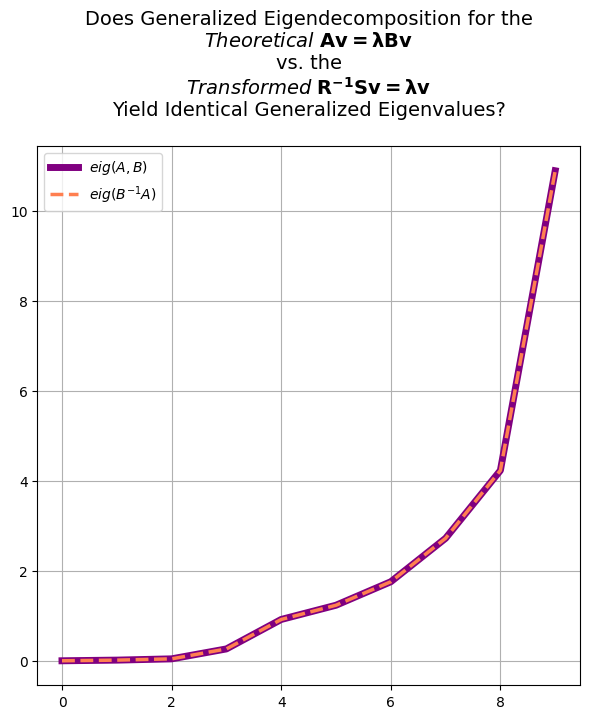

In [24]:
plt.figure(figsize=(7, 7))

plt.plot(
    evalsAB,
    lw=5,
    label="$eig(A, B)$",
    color="purple",
)
plt.plot(
    evalsBinvA,
    ls="--",
    lw=2.5,
    label="$eig(B^{-1}A)$",
    color="coral",
)

plt.grid()
# plt.axis("square")
plt.legend()

title = "Does Generalized Eigendecomposition for the\n"
title += "$\\mathit{Theoretical}$ $\\mathbf{A v = \\lambda B v}$\n"
title += "vs. the\n$\\mathit{Transformed}$ $\\mathbf{R^{-1} S v = \\lambda v}$\n"
title += "Yield Identical Generalized Eigenvalues?\n"
plt.title(title, size=14)

plt.show()

It would appear so.

**_Eigenvector Structure Comparison (NOT Exact Matching)_**

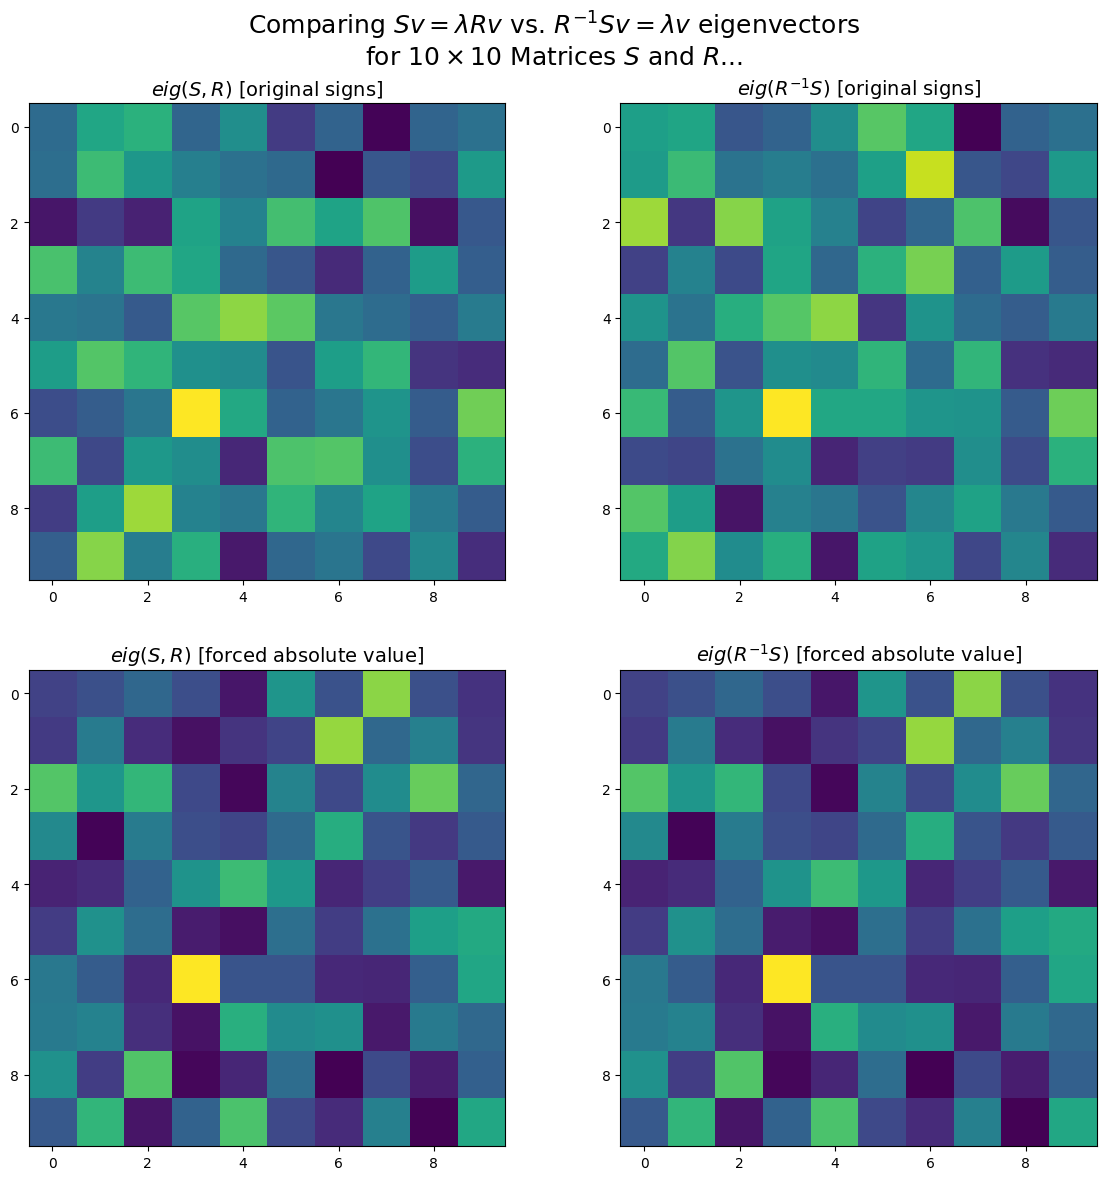

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0][0].imshow(evecsAB)
axes[0][0].set_title("$eig(S, R)$ [original signs]", size=14)

axes[0][1].imshow(evecsBinvA)
axes[0][1].set_title("$eig(R^{-1}S)$ [original signs]", size=14)

axes[1][0].imshow(np.abs(evecsAB))
axes[1][0].set_title("\n$eig(S, R)$ [forced absolute value]", size=14)

axes[1][1].imshow(np.abs(evecsBinvA))
axes[1][1].set_title("\n$eig(R^{-1}S)$ [forced absolute value]", size=14)

sup_title = "Comparing $Sv = \\lambda R v$ vs. $R^{-1} S v = \\lambda v$ eigenvectors\n"
sup_title += f"for ${N} \\times {N}$ Matrices $S$ and $R$..."
fig.suptitle(sup_title, size=18)

fig.tight_layout()
plt.show()

Raw eigenvector matrices with disparate signs have close similarity.

Applying `abs()` to eigenvector matrices demonstrates correspondence more clearly.

<hr style="height: 0; box-shadow: 0 0 5px 4px dodgerblue; width: 80%;">

### **_Takeaway_**

My understanding is still pretty basic, but...

While using well-conditioned, invertible matrices:

- Also not relying on explicit matrix inversion and instead using `np.linalg.solve()`...

this notebook has used two methods:

- $A v = \lambda B v$

- $B^{-1}A v = \lambda v$

...to produce matching eigenvalues and corresponding eigenvectors.

It hasn't proven strict equality of outputs: only equivalence of spectral information and structure.

This was also a good chance to do some good reps, safely and efficiently making use of Python and its libraries to perform Generalized Eigendecomposition.

<hr style="height: 0; box-shadow: 0 0 5px 4px crimson; width: 95%;">


## **_Attribution_**

This notebook explores and reviews subjects I studied in Mike X. Cohen's Linear Algebra course on Udemy.

It's a chance for me to practice the concepts covered and to build a quick-reference.

Mike's info:

-   [**_Udemy Course_**](https://www.udemy.com/course/linear-algebra-theory-and-implementation)

-   [**_Mike X. Cohen's Website_**](https://www.mikexcohen.com/)

<hr style="height: 0; box-shadow: 0 0 5px 4px crimson; width: 90%;">


<font size=5 style="font-family: Courier; font-weight: 700; text-align: center; color: ivory; text-shadow: orangered 0.05rem 0.05rem 0.65rem, goldenrod 0.05rem -0.05rem 0.65rem, dodgerblue -0.05rem -0.05rem 0.65rem; magenta -0.05rem 0.05rem 0.65rem">

All stable processes we shall predict.
<br>

<font size=4>_All unstable processes we shall control._</font>

<font size=2>_JvN_</font>

</font>

<hr style="height: 0; box-shadow: 0 0 5px 4px crimson; width: 90%;">


<hr style="height: 0; box-shadow: 0 0 5px 4px dodgerblue; width: 80%;">

<hr style="height: 0; box-shadow: 0 0 5px 4px #5EDC1F; width: 70%;">

<hr style="height: 0; box-shadow: 0 0 5px 4px orangered; width: 60%;">

<hr style="height: 0; box-shadow: 0 0 5px 4px gold; width: 50%;">

<hr style="height: 0; box-shadow: 0 0 5px 4px mediumorchid; width: 40%;">

<font size=2>

_Andrew Blais, Boston, Massachusetts_

GitHub: https://github.com/andrewblais

Website/Python Web Development Portfolio: https://wateronchair.com/

</font>